<a href="https://colab.research.google.com/github/shumailas709/Data-Analytic-Portfolio-/blob/main/Wine_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Project 6 - Wine Quality Prediction
# Author: Shumaila Shaikh

from google.colab import files
uploaded = files.upload()


Saving WineQT.csv to WineQT.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv('WineQT.csv')

# First look
print("First 5 rows:")
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nWine Quality Distribution:")
print(df['quality'].value_counts())


First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5 

In [3]:
# Step 2: Train Random Forest Model

X = df.drop(['quality', 'Id'], axis=1)
y = df['quality']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(
    n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 70.3%

Classification Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.72      0.80      0.76        96
           6       0.68      0.67      0.67        99
           7       0.72      0.69      0.71        26
           8       0.00      0.00      0.00         2

    accuracy                           0.70       229
   macro avg       0.42      0.43      0.43       229
weighted avg       0.68      0.70      0.69       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


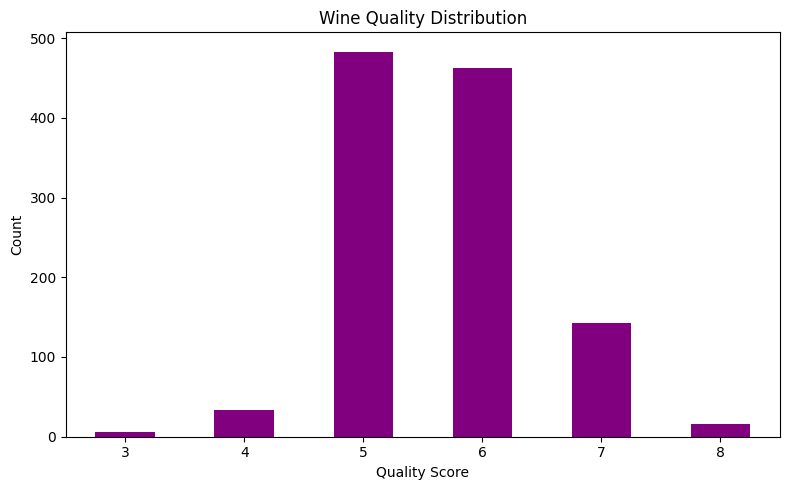

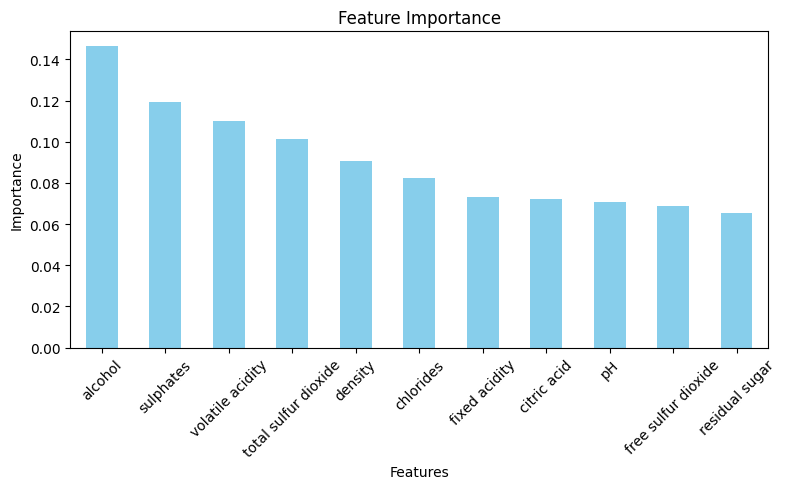

Top 3 features:
alcohol             0.146276
sulphates           0.119159
volatile acidity    0.110288
dtype: float64


In [4]:
# Step 3: Visualization

# Chart 1: Wine Quality Distribution
plt.figure(figsize=(8,5))
df['quality'].value_counts().sort_index().plot(
    kind='bar', color='purple')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Chart 2: Feature Importance
feature_imp = pd.Series(
    model.feature_importances_,
    index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_imp.plot(kind='bar', color='skyblue')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Top 3 features:")
print(feature_imp.head(3))


In [5]:
# Step 4: Final Insights
print("="*40)
print("WINE QUALITY PREDICTION INSIGHTS")
print("="*40)

print("\n📊 Dataset Info:")
print("Total wines: 1143")
print("Features: 11 chemical properties")

print("\n🤖 Model Performance:")
print("Algorithm: Random Forest")
print("Accuracy: 70.3%")

print("\n🍷 Key Findings:")
print("- Most wines = Quality 5 & 6")
print("- Best quality wines = very rare!")
print("- Alcohol = #1 quality factor")
print("- Sulphates = #2 quality factor")
print("- Volatile Acidity = #3 factor")

print("\n💡 RECOMMENDATIONS:")
print("- Higher alcohol = better quality")
print("- Control volatile acidity")
print("- Optimize sulphate levels")
print("="*40)


WINE QUALITY PREDICTION INSIGHTS

📊 Dataset Info:
Total wines: 1143
Features: 11 chemical properties

🤖 Model Performance:
Algorithm: Random Forest
Accuracy: 70.3%

🍷 Key Findings:
- Most wines = Quality 5 & 6
- Best quality wines = very rare!
- Alcohol = #1 quality factor
- Sulphates = #2 quality factor
- Volatile Acidity = #3 factor

💡 RECOMMENDATIONS:
- Higher alcohol = better quality
- Control volatile acidity
- Optimize sulphate levels
